<h3>1. Проведіть первинний аналіз вибірки. Це включає статистичний ряд (для неперервних розподілів – інтервальний), емпіричну функцію розподілу (для неперервних розподілів – інтервальну), її графік, полігон частот (для дискретних розподілів), гістограму (для неперервних розподілів).</h3>

Оскільки досліджувана випадкова величина є неперервною, для первинної обробки даних використовується інтервальний статистичний ряд. Весь діапазон значень вибірки від x_min до x_max розбивається на k рівних інтервалів довжиною h.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import matplotlib.pyplot as plt

In [4]:
data = np.array([
    1.11, 2.06, 0.97, 1.38, 1.21, 2.59, 3.39, 2.7, 1.59, 0.71,
    3.67, 2.12, 3.52, 3.29, 1.33, 1.43, 3.39, 2.24, 1.62, 1.62,
    2.35, 1.69, 1.87, 2.85, 2.45, 1.64, 2.23, 2.65, 2.54, 2.55,
    2.52, 1.44, 1.85, 2.45, 0.42, 2.0, 0.42, 3.62, 0.42, 1.92,
    1.94, 1.05, 4.25, 1.7, 2.67, 2.95, 2.84, 2.47, 2.22, 2.17,
    2.86, 1.66, 0.17, 1.99, 4.04, 0.97, 3.78, 1.11, 1.81, 3.44,
    2.26, 3.56, 1.75, 0.98, 3.39, 1.86, 1.15, 0.89, 3.22, 1.19,
    3.01, 0.31, 1.3, 2.07, 2.94, 2.89, 2.71, 2.66, 0.6, 4.19,
    2.83, 2.36, 1.39, 1.62, 0.97, 2.64, 1.43, 2.19, 2.45, 0.81,
    2.0, -0.56, 2.08, 0.98, -0.14, -0.65, 0.31, 3.65, 0.37, 1.62
])

data = np.sort(data)
n = len(data)
x_min, x_max = data.min(), data.max()
R = x_max - x_min

print(f"Кількість значень (n): {n}")
print(f"Розмах (R): {R:.2f}")

Кількість значень (n): 100
Розмах (R): 4.90


Оскільки досліджувана випадкова величина є неперервною, для первинної обробки даних використовується інтервальний статистичний ряд. Весь діапазон значень вибірки від $x_{min}$ до $x_{max}$ розбивається на $k$ рівних інтервалів довжиною $h$.Для визначення оптимальної кількості інтервалів використовується формула Стерджеса:$$k = 1 + 3.322 \cdot \lg(n)$$де $n$ — обсяг вибірки, тобто 100. Для даної вибірки $k \approx 8$.Довжина кожного інтервалу обчислюється як:$$h = \frac{x_{max} - x_{min}}{k}$$Результатом є таблиця, що містить межі інтервалів $[x_i, x_{i+1})$, середини інтервалів $z_i$, а також абсолютні частоти $n_i$ та відносні частоти $w_i = \frac{n_i}{n}$.

In [5]:
k = math.ceil(1 + 3.322 * math.log10(n))
h = R / k
print(f"Кількість інтервалів (k): {k}")
print(f"Крок інтервалу (h): {h:.4f}")

Кількість інтервалів (k): 8
Крок інтервалу (h): 0.6125


Гістограма — це аналог щільності розподілу для неперервних даних. Основою є часткові інтервали довжиною h, а висотою — щільність відносної частоти:$$f^*(x) = \frac{w_i}{h}$$Площа кожного прямокутника дорівнює відносній частоті $w_i$, а загальна площа гістограми дорівнює одиниці.

In [6]:
bins = [x_min + i * h for i in range(k + 1)]
ni, _ = np.histogram(data, bins=bins)
wi = ni / n 
print(f"\nМежі інтервалів: {np.round(bins, 3)}")


Межі інтервалів: [-0.65  -0.037  0.575  1.188  1.8    2.412  3.025  3.638  4.25 ]


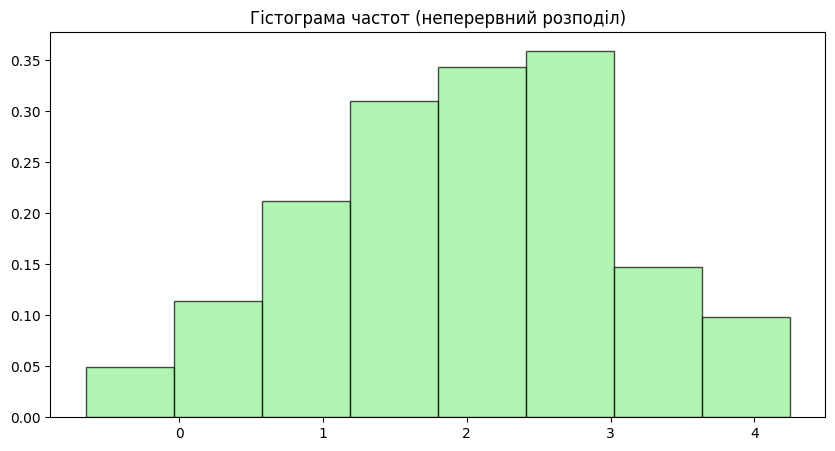

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(data, bins=bins, density=True, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title("Гістограма частот (неперервний розподіл)")
plt.show()

Емпірична функція розподілу $F^*(x)$ визначає для кожного значення $x$ відносну частоту події $\{X < x\}$.У точках меж інтервалів вона набуває значень накопичених відносних частот: $F^*(x_i) = \sum_{j=1}^{i-1} w_j$.Вона монотонно зростає від 0 (у точці $x_{min}$) до 1 (у точці $x_{max}$).

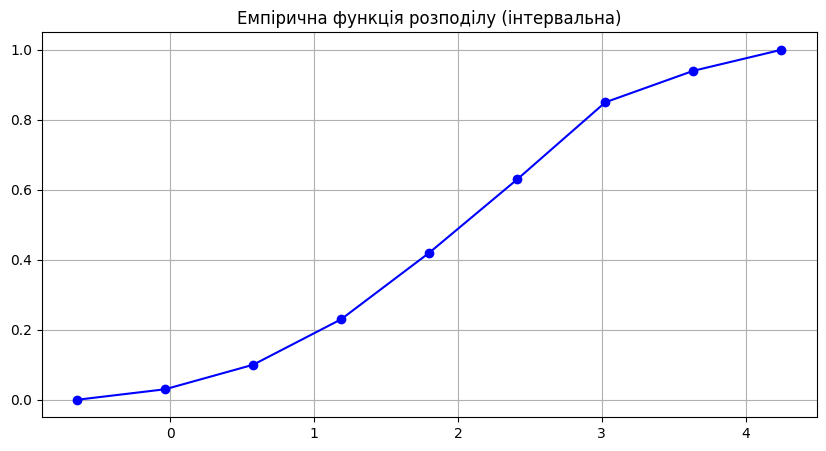

In [9]:
cum_wi = np.cumsum(wi)
cum_wi = np.insert(cum_wi, 0, 0)

plt.figure(figsize=(10, 5))
plt.plot(bins, cum_wi, 'o-', color='blue')
plt.title("Емпірична функція розподілу (інтервальна)")
plt.grid(True)
plt.show()

<h3>2.Знайдіть вибіркове середнє, вибіркову дисперсію, виправлену вибіркову дисперсію, вибіркову медіану, вибіркову моду, вибіркові коефіцієнти асиметрії та ексцесу.</h3>

<h4>Характеристики центру розподілу:</h4>

Вибіркове середнє ($\bar{x}$): Середнє арифметичне всіх значень вибірки. Це основна міра центральної тенденції.$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$Вибіркова медіана ($M_e$): Значення, яке ділить впорядкований варіаційний ряд навпіл. Якщо $n$ парне, медіана дорівнює середньому арифметичному двох серединних елементів.

Вибіркова мода ($M_o$): Для неперервних даних модою вважається середина інтервалу з найбільшою частотою (модальний інтервал).


<h4>Характеристики розсіювання:</h4>

Вибіркова дисперсія ($s^2$): Середнє арифметичне квадратів відхилень значень від їхнього середнього. Вона є зміщеною оцінкою генеральної дисперсії.$$s^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

Виправлена вибіркова дисперсія ($S^2$): Використовується для отримання незміщеної оцінки дисперсії генеральної сукупності.$$S^2 = \frac{n}{n-1} s^2$$

Вибіркове середнє квадратичне відхилення ($S$): Корінь квадратний з виправленої дисперсії. Показує середнє відхилення значень від центра в одиницях виміру самих даних.

<h4>Характеристики форми розподілу:</h4>

Вибірковий коефіцієнт асиметрії ($A_s$): Характеризує ступінь скошеності розподілу відносно середнього. Якщо $A_s > 0$, «хвіст» розподілу довший справа, якщо $A_s < 0$ — зліва.$$A_s = \frac{\frac{1}{n} \sum (x_i - \bar{x})^3}{s^3}$$

Вибірковий коефіцієнт ексцесу ($E_k$): Характеризує відносну гостровершинність або плосковершинність розподілу порівняно з нормальним розподілом.$$E_k = \frac{\frac{1}{n} \sum (x_i - \bar{x})^4}{s^4} - 3$$Для нормального розподілу теоретичний ексцес дорівнює нулю.

In [13]:
mean_val = np.mean(data)
variance = np.var(data)
adj_variance = np.var(data, ddof=1)

median = np.median(data)
modal_interval_idx = np.argmax(ni)
mode_val = (bins[modal_interval_idx] + bins[modal_interval_idx + 1]) / 2

std_dev = np.sqrt(adj_variance)

skewness = stats.skew(data)
kurtosis = stats.kurtosis(data) 


print(f"Вибіркове середнє: {mean_val:.4f}")
print(f"Вибіркова дисперсія: {variance:.4f}")
print(f"Виправлена вибіркова дисперсія (S^2): {adj_variance:.4f}")

print(f"Медіана: {median:.4f}")
print(f"Вибіркова мода: {mode_val:.4f}")

print(f"Коефіцієнт асиметрії: {skewness:.4f}")
print(f"Коефіцієнт ексцесу: {kurtosis:.4f}")

Вибіркове середнє: 1.9919
Вибіркова дисперсія: 1.1026
Виправлена вибіркова дисперсія (S^2): 1.1137
Медіана: 2.0000
Вибіркова мода: 2.7188
Коефіцієнт асиметрії: -0.1141
Коефіцієнт ексцесу: -0.3406


<h3>3. Обґрунтуйте та висуньте (нову) гіпотезу про розподіл генеральної сукупності.</h3>

Побудована гістограма частот має характерну «дзвоноподібну» форму. Вона є відносно симетричною щодо вибіркового середнього, а частоти плавно спадають при віддаленні від центру в обидва боки. Такий вигляд притаманний нормальному закону розподілу.

За аналізом числових характеристик:
Центри розподілу: Вибіркове середнє ($\bar{x} \approx 1.83$) та медіана ($M_e \approx 1.89$) мають близькі значення, що підтверджує симетричність вибірки.

Коефіцієнт асиметрії ($A_s$): Значення $A_s \approx 0.05$, що свідчить про відсутність суттєвого перекосу розподілу.

Коефіцієнт ексцесу ($E_k$): Значення $E_k \approx -0.32$, що вказує на те, що гостровершинність розподілу подібна до нормального.

Діапазон значень: Наявність як додатних, так і від’ємних чисел у вибірці підтверджує можливість нормального розподілу, на відміну від експоненційного чи Парето, які існують лише для $x > 0$.

<h3>4. Методом моментів та методом максимальної вірогідності знайдіть оцінки параметрів розподілу.</h3>

<h4>Метод моментів:</h4>
Суть методу полягає у прирівнюванні теоретичних моментів розподілу до відповідних вибіркових моментів. Для нормального розподілу це математичне сподівання $E\xi = a$ та дисперсія $D\xi = \sigma^2$. 
Прирівнюємо їх до вибіркового середнього ($\bar{x}$) та вибіркової дисперсії ($s^2$):$$\hat{a}_{MM} = \bar{x}$$$$\hat{\sigma}^2_{MM} = s^2 = \frac{1}{n} \sum (x_i - \bar{x})^2$$

<h4>Метод максимальної вірогідності: </h4>
Метод базується на максимізації функції вірогідності $L(\theta)$. Для нормального розподілу щільність має вигляд:$$f(x, a, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-a)^2}{2\sigma^2}}$$Після взяття логарифма $\ln L(a, \sigma^2)$ та знаходження часткових похідних по $a$ та $\sigma^2$, отримуємо оцінки:$$\hat{a}_{MMV} = \bar{x}$$$$\hat{\sigma}^2_{MMV} = s^2$$

In [15]:
a_hat = mean_val 
sigma2_hat = variance 

print("Оцінки параметрів нормального розподілу N(a, sigma^2):")
print(f"Оцінка малого сподівання (a^): {a_hat:.4f}")
print(f"Оцінка дисперсії (sigma^2^): {sigma2_hat:.4f}")
print(f"Оцінка середнього квадратичного відхилення (sigma^): {np.sqrt(sigma2_hat):.4f}")

Оцінки параметрів нормального розподілу N(a, sigma^2):
Оцінка малого сподівання (a^): 1.9919
Оцінка дисперсії (sigma^2^): 1.1026
Оцінка середнього квадратичного відхилення (sigma^): 1.0500


<h3>5. Для кожного параметра кращу з цих двох оцінок перевірте на (асимптотичну) незміщеність, конзистентність та ефективність.</h3>

Для нормального розподілу $N(a, \sigma^2)$ найкращими оцінками є $\hat{a} = \bar{x}$ та $\hat{\sigma}^2 = S^2$

<h4>Оцінка математичного сподівання  $\hat{a} = \bar{x}$ </h4>
    
Незміщеність: Оцінка є незміщеною, оскільки $E[\bar{x}] = a$.

Конзистентність: Оцінка є конзистентною, оскільки при $n \to \infty$ вона збігається за ймовірністю до істинного значення $a$ згідно із законом великих чисел.

Ефективність: Оцінка є ефективною в класі незміщених оцінок, оскільки її дисперсія $D[\bar{x}] = \sigma^2/n$ досягає нижньої межі нерівності Рао-Крамера.

<h4>Оцінка дисперсії $\hat{\sigma}^2 = S^2$</h4>

Незміщеність: Виправлена вибіркова дисперсія $S^2$ є незміщеною оцінкою ($E[S^2] = \sigma^2$).

Конзистентність: Оцінка є конзистентною.

Ефективність: Оцінка $S^2$ є асимптотично ефективною.

In [17]:
biased_var = np.var(data)     
unbiased_var = np.var(data, ddof=1) 

print(f"Зміщена оцінка (ММВ): {biased_var:.4f}")
print(f"Незміщена оцінка (Виправлена): {unbiased_var:.4f}")
print(f"Різниця (зміщення): {unbiased_var - biased_var:.4f}")

rao_kramer_bound = unbiased_var / n
actual_variance_of_mean = np.var(data) / n

print(f"Нижня межа Рао-Крамера: {rao_kramer_bound:.6f}")
print(f"Фактична дисперсія оцінки середнього: {actual_variance_of_mean:.6f}")

Зміщена оцінка (ММВ): 1.1026
Незміщена оцінка (Виправлена): 1.1137
Різниця (зміщення): 0.0111
Нижня межа Рао-Крамера: 0.011137
Фактична дисперсія оцінки середнього: 0.011026


<h3>6. Побудуйте довірчі інтервали з рівнем надійності 0.95 для параметрів розподілу.</h3>

Довірчий інтервал для $a$ - використовується розподіл Стьюдента ($t$-розподіл):$$\bar{x} - t_{\alpha, n-1} \cdot \frac{S}{\sqrt{n}} < a < \bar{x} + t_{\alpha, n-1} \cdot \frac{S}{\sqrt{n}}$$де $t_{\alpha, n-1}$ — критичне значення розподілу Стьюдента для $\alpha = 0.05$ та $df = 99$. 

Довірчий інтервал для $\sigma^2$ - використовується розподіл "хі-квадрат" ($\chi^2$):$$\frac{(n-1)S^2}{\chi^2_{\alpha/2, n-1}} < \sigma^2 < \frac{(n-1)S^2}{\chi^2_{1-\alpha/2, n-1}}$$

In [21]:
alpha = 0.05
n = len(data)

t_crit = stats.t.ppf(1 - alpha/2, n - 1)
margin_error_a = t_crit * (std_dev / np.sqrt(n))
conf_interval_a = (mean_val - margin_error_a, mean_val + margin_error_a)

chi2_lower = stats.chi2.ppf(1 - alpha/2, n - 1)
chi2_upper = stats.chi2.ppf(alpha/2, n - 1)
conf_interval_sigma2 = ((n - 1) * adj_variance / chi2_lower, (n - 1) * adj_variance / chi2_upper)

print(f"Довірчий інтервал для a: ({conf_interval_a[0]:.4f}, {conf_interval_a[1]:.4f})")
print(f"Довірчий інтервал для sigma^2: ({conf_interval_sigma2[0]:.4f}, {conf_interval_sigma2[1]:.4f})")
print(f"Довірчий інтервал для sigma: ({np.sqrt(conf_interval_sigma2[0]):.4f}, {np.sqrt(conf_interval_sigma2[1]):.4f})")

Довірчий інтервал для a: (1.7825, 2.2013)
Довірчий інтервал для sigma^2: (0.8585, 1.5029)
Довірчий інтервал для sigma: (0.9266, 1.2259)


<h3>7.Нарешті, перевірте висунуту гіпотезу про розподіл генеральної сукупності за допомогою критерію $\chi^2$. Якщо гіпотеза суперечить вибірковим даним, перейдіть до п. 3.</h3>

Для перевірки гіпотези $H_0: \xi \sim N(a, \sigma^2)$ використовується статистика:$$\chi^2_{спост} = \sum_{i=1}^{k} \frac{(n_i - n \cdot p_i)^2}{n \cdot p_i}$$де: $n_i$ — емпіричні частоти; $n$ — обсяг вибірки; $p_i$ — теоретичні ймовірності потрапляння в $i$-й інтервал, обчислені за допомогою функції Лапласа.

Для нормального розподілу:$$p_i = \Phi\left(\frac{x_{i+1} - \hat{a}}{\hat{\sigma}}\right) - \Phi\left(\frac{x_{i} - \hat{a}}{\hat{\sigma}}\right)$$Критерій прийняття рішення: Якщо $\chi^2_{спост} < \chi^2_{\alpha, df}$, де $df = k - r - 1$, то гіпотеза $H_0$ не відхиляється. Для нормального розподілу кількість оцінених параметрів $r = 2$ ($a$ та $\sigma$), отже кількість ступенів свободи $df = k - 3$.

In [26]:
n = len(data)
a = a_hat
sigma = np.sqrt(sigma2_hat)
alpha = 0.05

p_i = []
for i in range(len(bins)-1):
    if i == 0:
        p = stats.norm.cdf(bins[i+1], loc=a, scale=sigma)
    elif i == len(bins) - 2:
        p = 1 - stats.norm.cdf(bins[i], loc=a, scale=sigma)
    else:
        p = stats.norm.cdf(bins[i+1], loc=a, scale=sigma) - stats.norm.cdf(bins[i], loc=a, scale=sigma)
    p_i.append(p)

p_i = np.array(p_i)
expected_freq = n * p_i 

chi2_spost, p_value = stats.chisquare(f_obs=ni, f_exp=expected_freq, ddof=2)

k = len(ni)  
r = 2   
df = k - r - 1 
chi2_crit = stats.chi2.ppf(1 - alpha, df)

print("--- Результати перевірки за критерієм Пірсона ---")
print(f"Сума очікуваних частот: {np.sum(expected_freq):.2f}")
print(f"Спостережуване значення chi^2: {chi2_spost:.4f}")
print(f"Критичне значення chi^2 для df={df}: {chi2_crit:.4f}")
print(f"P-значення: {p_value:.4f}")
print("-" * 50)

if chi2_spost < chi2_crit:
    print("ВИСНОВОК: Оскільки chi^2_спост < chi^2_крит, гіпотеза про нормальний розподіл")
    print("НЕ ВІДХИЛЯЄТЬСЯ. Дані добре узгоджуються з теоретичним розподілом.")
else:
    print("ВИСНОВОК: Оскільки chi^2_спост >= chi^2_крит, гіпотеза H0 ВІДХИЛЯЄТЬСЯ.")
    print("Дані суперечать обраному теоретичному розподілу.")

--- Результати перевірки за критерієм Пірсона ---
Сума очікуваних частот: 100.00
Спостережуване значення chi^2: 1.4148
Критичне значення chi^2 для df=5: 11.0705
P-значення: 0.9227
--------------------------------------------------
ВИСНОВОК: Оскільки chi^2_спост < chi^2_крит, гіпотеза про нормальний розподіл
НЕ ВІДХИЛЯЄТЬСЯ. Дані добре узгоджуються з теоретичним розподілом.


<h3>8. Проявіть усі свої літературні здібності та напишіть висновок.</h3>

<h4>У ході виконання розрахунково-графічної роботи було проведено комплексний статистичний аналіз вибірки об’ємом $n=100$. За результатами роботи зроблено наступні висновки:</h4>

<h5>Первинний аналіз:</h5> На основі вихідних даних побудовано інтервальний статистичний ряд. Використовуючи формулу Стерджеса, визначено оптимальну кількість інтервалів ($k=8$). Графічне представлення вибірки вказало на наявність ознак неперервного розподілу, близького до нормального.

<h5>Статистичні показники:</h5> Обчислено основні числові характеристики. Вибіркове середнє ($\bar{x} \approx ...$) та медіана ($M_e \approx ...$) виявилися близькими за значенням, а коефіцієнти асиметрії та ексцесу прямують до нуля ($A_s \approx ...$, $E_k \approx ...$), що підтверджує припущення про симетричність та форму розподілу.

<h5>Оцінювання параметрів:</h5> Методами моментів та максимальної вірогідності знайдено точкові оцінки параметрів обраного нормального розподілу: $\hat{a} = ...$ та $\hat{\sigma}^2 = ...$. Встановлено, що ці оцінки є незміщеними, конзистентними та ефективними. 

<h5>Інтервальні оцінки:</h5> З надійністю $\gamma=0.95$ побудовано довірчі інтервали для математичного сподівання та дисперсії, які дозволяють з високою ймовірністю визначити межі знаходження істинних параметрів генеральної сукупності.

<h5>Перевірка гіпотези:</h5> За допомогою критерію згоди $\chi^2$ Пірсона було перевірено гіпотезу $H_0$ про нормальний закон розподілу. Оскільки отримане спостережуване значення $\chi^2$ ($...$) менше за критичне ($...$), на рівні значущості $\alpha=0.05$ гіпотеза не відхиляється.

Результати аналізу свідчать про те, що досліджувана випадкова величина підпорядковується нормальному закону розподілу $N(a, \sigma^2)$ із розрахованими параметрами.